In [59]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

# Period of ERA5 used

In [9]:
iyear=1960
fyear=2025

# Domain 

In [10]:
dom='MA' # Middle Asia

# Atmospheric Circulation loading

In [11]:
#load eastward (u) and northward (v) of IVT
uivt = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/uivt_monthly_era5_1940-2025_NH_025x025.nc')
uivt = uivt.sel(valid_time=slice(f"{iyear}-01-01", f"{fyear}-12-31")) # only during the period wanted

vivt = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/vivt_monthly_era5_1940-2025_NH_025x025.nc')
vivt = vivt.sel(valid_time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

#load tcwv
tcwv = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/tcwv_monthly_era5_1940-2025_NH_025x025.nc')
tcwv = tcwv.sel(valid_time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

#focus on Middle Asia (MA)
uivt_MA = field_dom(uivt,dom)
vivt_MA = field_dom(vivt,dom)
tcwv_MA = field_dom(tcwv,dom)

# Climatology of atmospheric circulation

In [12]:
# season definition : DJFM (winter), AM (pre-monsoon), JJAS (monsoon), ON (post-monsoon)
seasons = ["DJFM", "AM", "JJAS", "ON"]

# period wanted
start_year = iyear
end_year = fyear

# dictionnary to store tcwv climatology
clim_dict = {}

# dictionnary to store uIVT & vIVT climatology
u_clim_dict = {}
v_clim_dict = {}

# rename time dimension for 'clim' function
tcwv_MA = tcwv_MA.rename({'valid_time': 'time'})
uivt_MA = uivt_MA.rename({'valid_time': 'time'})
vivt_MA = vivt_MA.rename({'valid_time': 'time'})

# climatology for each season for tcwv, uIVT, vIVT
for season in seasons:
    clim_season = clim(tcwv_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year) # function : a particular season + mean
    clim_dict[season] = clim_season
    
    u_clim_season = clim(uivt_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    u_clim_dict[season] = u_clim_season
    
    v_clim_season = clim(vivt_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    v_clim_dict[season] = v_clim_season

# Plot of seasonal atmospheric circulation over Middle Asia 

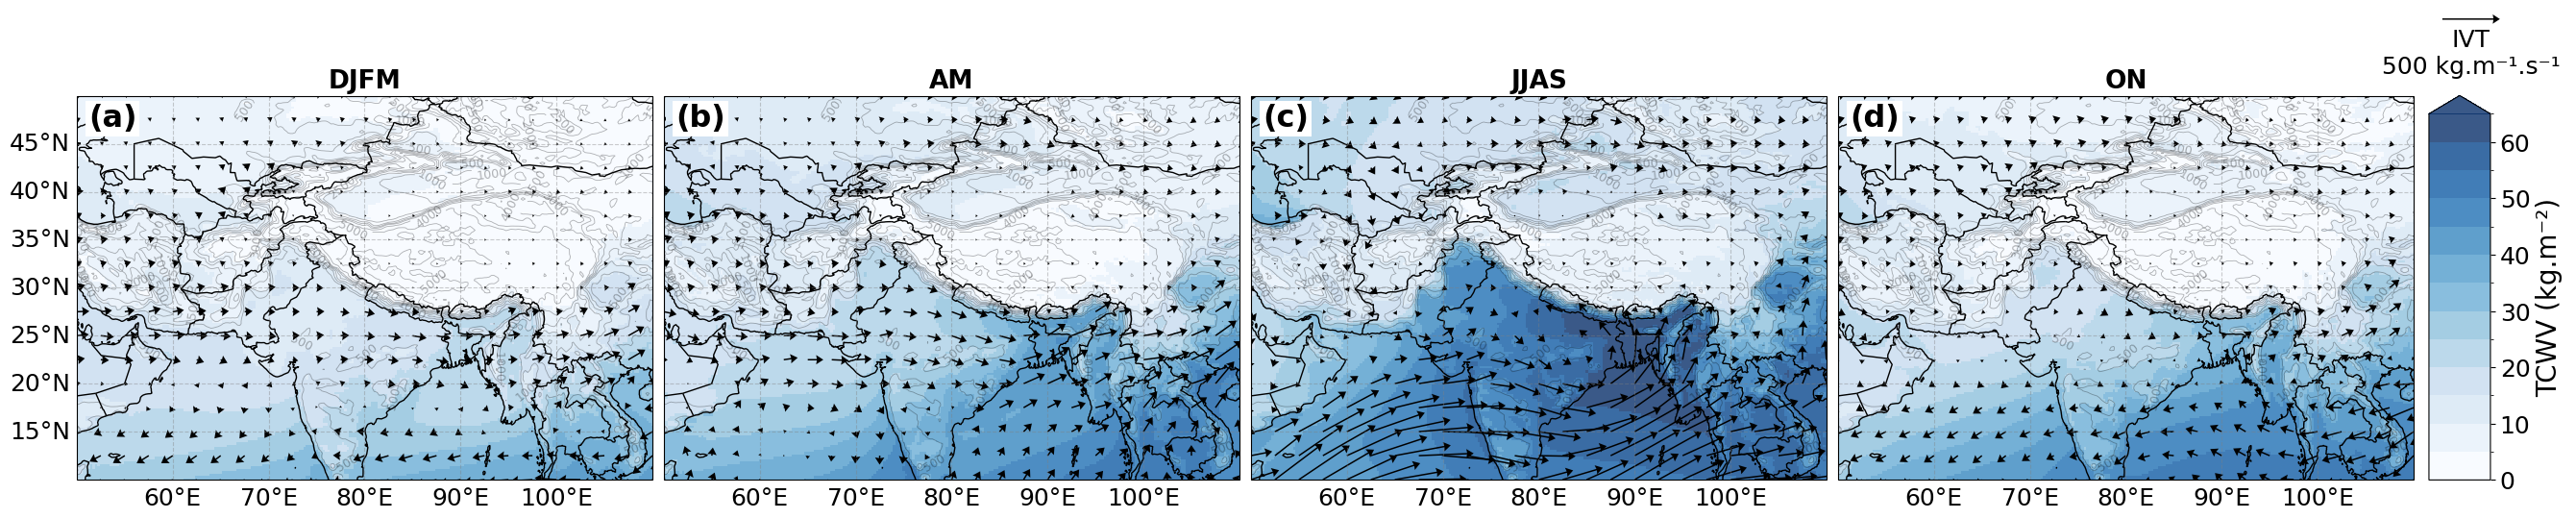

In [58]:
# elevation for courbe de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

# colorgrading for tcwv (blue shading), same for every season
step = 5
vmin = 0
vmax = max(ds["tcwv"].max().item() for ds in clim_dict.values()) # taking the maximum value across all region and year 
levels = np.arange(vmin, vmax, 5)
cmap = plt.get_cmap("Blues")
norm = mcolors.BoundaryNorm(levels, cmap.N)

# letters for the subplots
letters = ['a', 'b', 'c', 'd']

# figure
fig, axes = plt.subplots(1, 4, figsize=(32, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = clim_dict[season]['tcwv']

    # map of seasonal tcwv with blue shading
    im = ax.pcolormesh(data_season.longitude,data_season.latitude,data_season,transform=ccrs.PlateCarree(),
                       cmap=cmap,norm=norm,shading="auto", alpha=0.8)


    # map limitations (not exactly middle asia, smaller)
    ax.set_extent([float(50),float(110),float(10),float(50)], crs=ccrs.PlateCarree())

    # seasonal IVT vectors with uIVT & vIVT
    step = 10 # not every vector so that there isn't too much
    u_plot = u_clim_dict[season]["viwve"].isel(latitude=slice(None, None, step),longitude=slice(None, None, step)) # step on uIVT
    v_plot = v_clim_dict[season]["viwvn"].isel(latitude=slice(None, None, step),longitude=slice(None, None, step)) # step on uIVT
    q = ax.quiver(u_plot.longitude,u_plot.latitude,u_plot,v_plot,transform=ccrs.PlateCarree(),scale=5000,width=0.0025,headwidth=6.5
             ,rasterized=True, color='black') # map of the IVT vectors 

    # coastline and borders
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    # courbe de niveau
    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,1500,2000,2500,3000,4000,5000,6000,7000],
                    colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d") # label des courbes de niveau
    
    ax.set_title(season, fontsize=19, weight="bold") # label des saisons pour les subplots

    # grid for lon et lat (labels only on left and bottom)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i == 0)
    gl.bottom_labels = True
    gl.xlabel_style = {"size": 18}
    gl.ylabel_style = {"size": 18}

    # letter for the subplot top-left
    ax.text(0.02, 0.98,f'({letters[i]})',transform=ax.transAxes,fontsize=23,fontweight='bold',va='top',ha='left',
            bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=2))

# colorbar for tcwv (blue shading)
cbar_ax = fig.add_axes([0.845, 0.15, 0.02, 0.4]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical", extend='max')
cbar.set_label("TCWV (kg.m⁻²)", fontsize=20)
cbar.ax.tick_params(labelsize=18)

# legend for IVT vectors
axkey = fig.add_axes([0.84, 0.58, 0.05, 0.06], frameon=False) # create a small invisible axis in the upper-right corner of the figure
axkey.set_axis_off()
axkey.quiverkey(q,1.1, 1.2, 500,"IVT\n500 kg.m⁻¹.s⁻¹",coordinates='axes',labelpos='S',fontproperties={'size': 18})

fig.subplots_adjust(left=0.08, right=0.84, top=0.82, bottom=-0.12, wspace=0.02, hspace=0)
plt.show()

# Precipitation data loading

### Precipitation domain for HMA only and not MA

In [61]:
dom='HMA'
latS,latN,lonW,lonE = coord_domain(dom)

In [62]:
# ERA5 (1960-2025)
tp1 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1940-2025_ERA5.nc')['tp']
tp1 = field_dom(tp1, dom) # focus on HMA
tp1 = tp1.sel(time=slice(str(iyear),str(fyear))) # focus on the period wanted 1960-2025

# CHIRPS (1981-2024)
tp2 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1981-2025_CHIRPS.nc')['tp']
tp2 = field_dom(tp2, dom)
tp2 = tp2.sel(time=slice(str(1981),str(2024))) # fovus on the period available for CHIRPS 1981-2024

# Climatology of precipitation

In [63]:
# season definition : DJFM (winter), AM (pre-monsoon), JJAS (monsoon), ON (post-monsoon)
seasons = ["DJFM","AM","JJAS","ON"]

# ERA5
tp1_dict = {} # dictionnary to store precipitation climatology ERA5
for season in seasons:
    tp1_season = clim(tp1, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
    tp1_dict[season] = tp1_season

# CHIRPS
tp2_dict = {} # dictionnary to store precipitation climatology CHIRPS
for season in seasons:
    tp2_season = clim(tp2, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
    tp2_dict[season] = tp2_season

# Plot of seasonal precipitation over High Mountain Asia

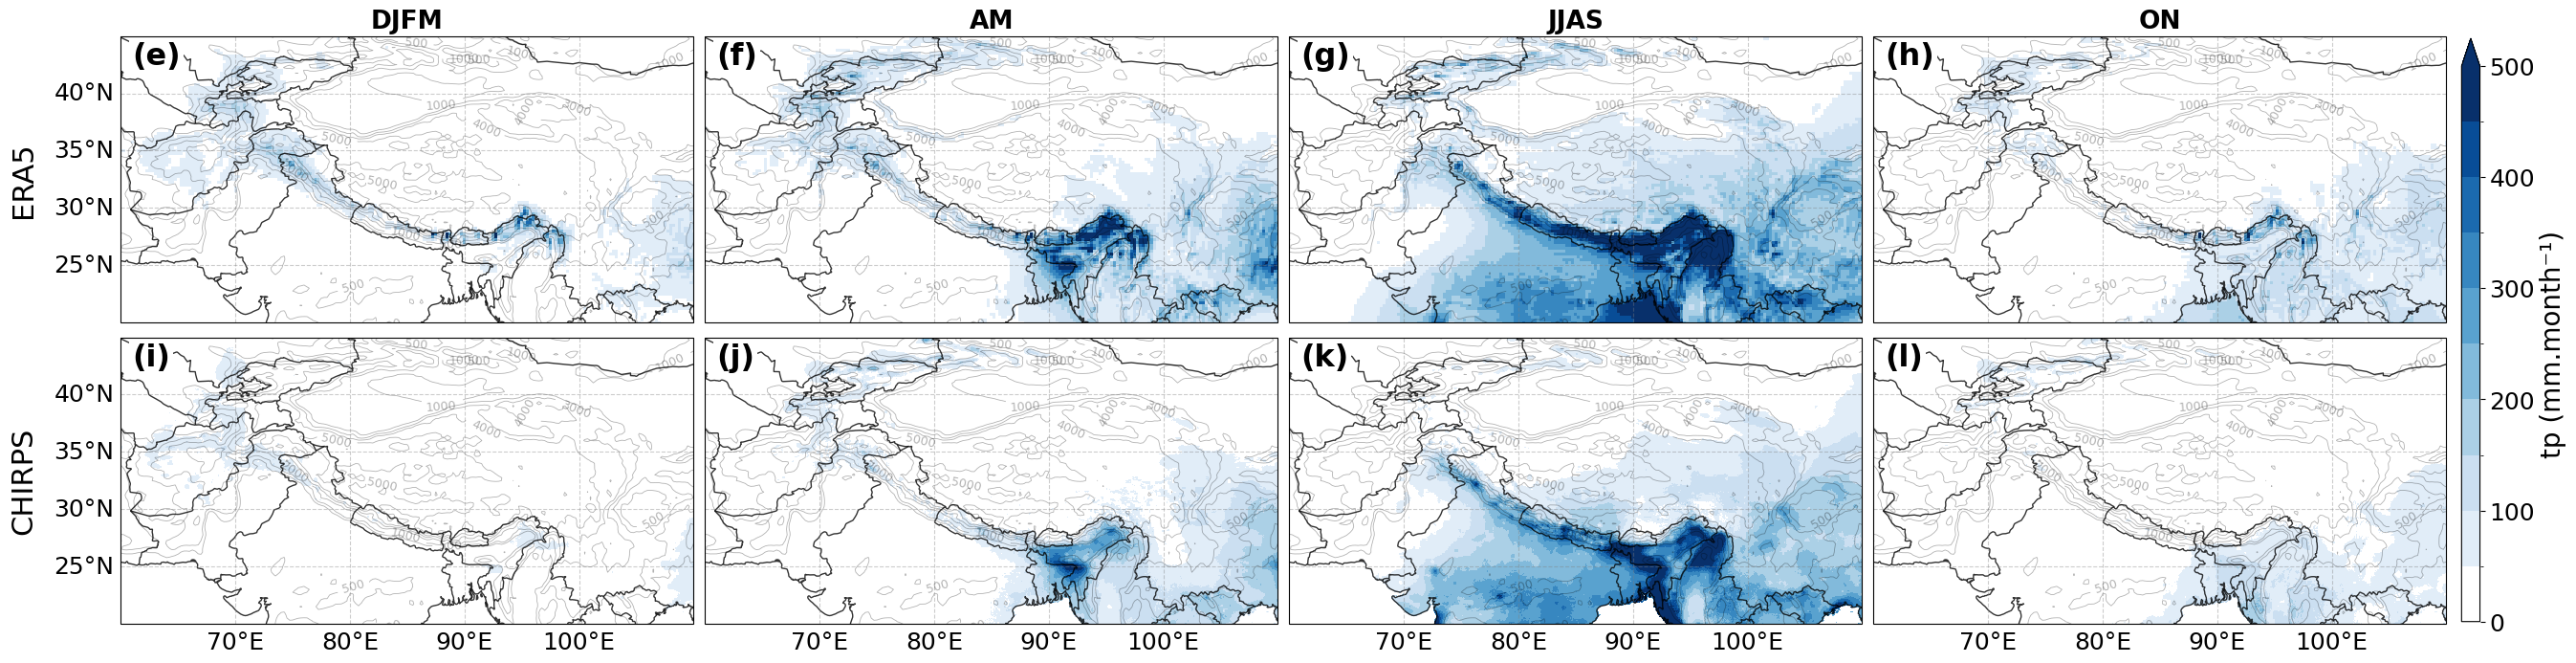

In [89]:
# colorgrading for precipitation (tp) (blue shading), same for every season
step = 50
vmax = 550
levels = np.arange(0, vmax, step)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1] # forcer la première couleur en tant que blanc
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))

# letters for the subplots
letters = ['e', 'f', 'g', 'h', 'i', 'j', 'k', 'l']

# figure
fig, axes = plt.subplots(2, 4, figsize=(32, 6.7), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i in [0,1,2,3]:
        season = seasons[i]
    if i in [4,5,6,7]:
        season = seasons[i-4]

    if i in [0,1,2,3]:
        data_season = tp1_dict[season]
    if i in [4,5,6,7]:
        data_season = tp2_dict[season]
    
    # map of seasonal precipitation with blue shading
    im = ax.pcolormesh(data_season['lon'], data_season['lat'], data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")


    # map limitations (HMA)
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    # coastline and borders
    ax.add_feature(cfeature.COASTLINE, linewidth=1,alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-",alpha=0.8)

    # courbe de niveau
    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                    colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d") # label des courbes de niveau

    if i in [0,1,2,3]:
        ax.set_title(season, fontsize=19, weight="bold") # label des saisons pour les subplots

    # grid for lon et lat (labels only on left and bottom)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    if i in [0,4]:
        gl.left_labels = True
    else:
        gl.left_labels = False
    if i in [4,5,6,7]:
        gl.bottom_labels = True
    else:
        gl.bottom_labels = False
    gl.xlabel_style = {"size": 18}
    gl.ylabel_style = {"size": 18}

    # letter for the subplot top-left
    ax.text(0.02, 0.98,f'({letters[i]})',transform=ax.transAxes,fontsize=23,fontweight='bold',va='top',ha='left',
            bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=2))

# colorbar for precipitation (blue shading)
cbar_ax = fig.add_axes([0.845, -0.105, 0.006, 0.91]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical", extend='max')
cbar.set_label("tp (mm.month⁻¹)", fontsize=20)
cbar.ax.tick_params(labelsize=18)

# labels des lignes (datasets)
axes[0].text(-0.17, 0.5, "ERA5",transform=axes[0].transAxes,fontsize=22,va="center", ha="center",rotation=90) # ERA5
axes[4].text(-0.17, 0.5, "CHIRPS",transform=axes[4].transAxes,fontsize=22,va="center", ha="center",rotation=90) # CHIRPS

fig.subplots_adjust(left=0.08, right=0.84, top=0.82, bottom=-0.12, wspace=0.02, hspace=0)
plt.show()

Figure 4. Seasonal Atmospheric Circulation and Precipitation (1960-2025) : (a-d) Data is from ERA5 (1960-2025). TCWV : Total Column of Water Vapor in kg.m-2, IVT : Integrated water Vapor Transport in kg.m-1.s-1. (e-l) Precipitation (tp, mm.month-1) is from ERA5 (1960-2025) (e-h) and CHIRPS (1981-2024) (i-l). Red boxes represent the subregions we defined (Fig. 2). Light gray lines represent contour lines on the ERA5 grid. Black lines denote political borders.